# 🎵 Music Genre Classification from Spectrograms
### Complete Pipeline: Data Preparation → Augmentation → Training → Evaluation

**Setup summary:**
- 1000 tracks × 10 genres = 10,000 raw tracks
- 5s segments with 50% overlap → ~110,000 segments
- Track-level train/val/test split (no leakage)
- Small CNN with ELU, BatchNorm, GlobalAveragePooling
- SpecAugment data augmentation
- EarlyStopping + ReduceLROnPlateau

## 1. Imports & Configuration

In [ ]:
import os
import random
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from pathlib import Path
from tqdm import tqdm

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Dense, Dropout,
    BatchNormalization, GlobalAveragePooling2D, ELU
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
)
from tensorflow.keras.regularizers import l2

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

# Reproducibility
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Audio / Spectrogram Config
SR = 22050
SEGMENT_DURATION = 3.0
OVERLAP = 0.5
N_MELS = 128
N_FFT = 2048
HOP_LENGTH = 512

# Training Config
BATCH_SIZE = 32
EPOCHS = 150
LEARNING_RATE = 1e-3
TEST_SIZE = 0.15
VAL_SIZE = 0.15

# Local dataset path (GTZAN-like structure)
# Expected layout:
#   Data 2/genres_original/<genre>/*.wav
DATA_ROOT = Path('Data 2/genres_original')
if not DATA_ROOT.exists():
    raise FileNotFoundError(
        f'Expected dataset folder not found: {DATA_ROOT}. '        'Update DATA_ROOT to your local path.'
    )

print('TensorFlow version:', tf.__version__)
print('GPU available:', bool(tf.config.list_physical_devices('GPU')))
print('DATA_ROOT:', DATA_ROOT.resolve())


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
TensorFlow version: 2.19.0
GPU available: True


## 2. Data Loading & Segment Extraction

In [ ]:
def extract_segments(audio_path, segment_duration=SEGMENT_DURATION,
                     overlap=OVERLAP, sr=SR,
                     n_mels=N_MELS, n_fft=N_FFT, hop_length=HOP_LENGTH):
    """
    Load one audio file and slice it into overlapping mel spectrogram segments.
    Returns list of (n_mels, time_frames) arrays normalised to [0, 1].
    """
    try:
        y, sr_ = librosa.load(audio_path, sr=sr, mono=True)
    except Exception as e:
        print(f'  [SKIP] {audio_path}: {e}')
        return []

    segment_samples = int(segment_duration * sr_)
    hop_samples     = int(segment_samples * (1 - overlap))

    segments = []
    start = 0
    while start + segment_samples <= len(y):
        chunk  = y[start : start + segment_samples]
        mel    = librosa.feature.melspectrogram(
                     y=chunk, sr=sr_, n_mels=n_mels,
                     n_fft=n_fft, hop_length=hop_length)
        mel_db = librosa.power_to_db(mel, ref=np.max)
        # Normalise to [0, 1]
        mel_db = (mel_db - mel_db.min()) / (mel_db.max() - mel_db.min() + 1e-6)
        segments.append(mel_db.astype(np.float32))
        start += hop_samples

    return segments


def load_dataset(data_root):
    """
    Walk data_root/<genre>/*.wav, extract segments, record track IDs.
    Returns:
        segments   : list of (n_mels, time_frames) arrays
        raw_labels : list of genre strings (one per segment)
        track_ids  : list of int track index (one per segment)
    """
    segments, raw_labels, track_ids = [], [], []
    track_counter = 0

    genre_dirs = sorted([d for d in Path(data_root).iterdir() if d.is_dir()])
    print(f'Found {len(genre_dirs)} genres: {[d.name for d in genre_dirs]}')

    for genre_dir in genre_dirs:
        audio_files = sorted(
            [f for f in (list(genre_dir.glob('*.wav')) +
                         list(genre_dir.glob('*.mp3')) +
                         list(genre_dir.glob('*.au')))
             if not f.name.startswith('._')]
        )
        print(f'  {genre_dir.name:15s}: {len(audio_files)} tracks')

        for audio_path in tqdm(audio_files, desc=genre_dir.name, leave=False):
            segs = extract_segments(audio_path)
            for seg in segs:
                segments.append(seg)
                raw_labels.append(genre_dir.name)
                track_ids.append(track_counter)
            track_counter += 1

    return segments, raw_labels, np.array(track_ids)


segments, raw_labels, track_ids = load_dataset(DATA_ROOT)

# Stack into array and add channel dim for Conv2D
X = np.array(segments)[..., np.newaxis]   # (N, n_mels, time_frames, 1)
print(f'\nTotal segments : {len(X):,}')
print(f'Spectrogram shape: {X.shape[1:]}')

Found 10 genres: ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']
  blues          : 100 tracks


  classical      : 100 tracks


  country        : 100 tracks


  disco          : 100 tracks


  hiphop         : 100 tracks


...

  metal          : 100 tracks


  pop            : 100 tracks


  reggae         : 100 tracks


  rock           : 100 tracks



Total segments : 18,972
Spectrogram shape: (128, 130, 1)


## 3. Label Encoding

Classes: ['blues' 'classical' 'country' 'disco' 'hiphop' 'jazz' 'metal' 'pop'
 'reggae' 'rock']
Encoded labels (first 10): [0 0 0 0 0 0 0 0 0 0]


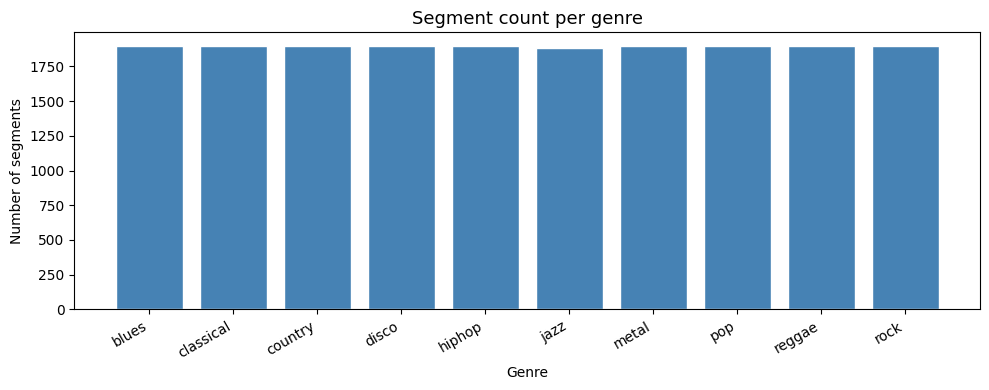

In [ ]:
le = LabelEncoder()
y  = le.fit_transform(raw_labels)

num_classes = len(le.classes_)
print('Classes:', le.classes_)
print('Encoded labels (first 10):', y[:10])

# Segment distribution per genre
unique, counts = np.unique(raw_labels, return_counts=True)
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(unique, counts, color='steelblue', edgecolor='white')
ax.set_title('Segment count per genre', fontsize=13)
ax.set_xlabel('Genre')
ax.set_ylabel('Number of segments')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

## 4. Visualise Sample Spectrograms

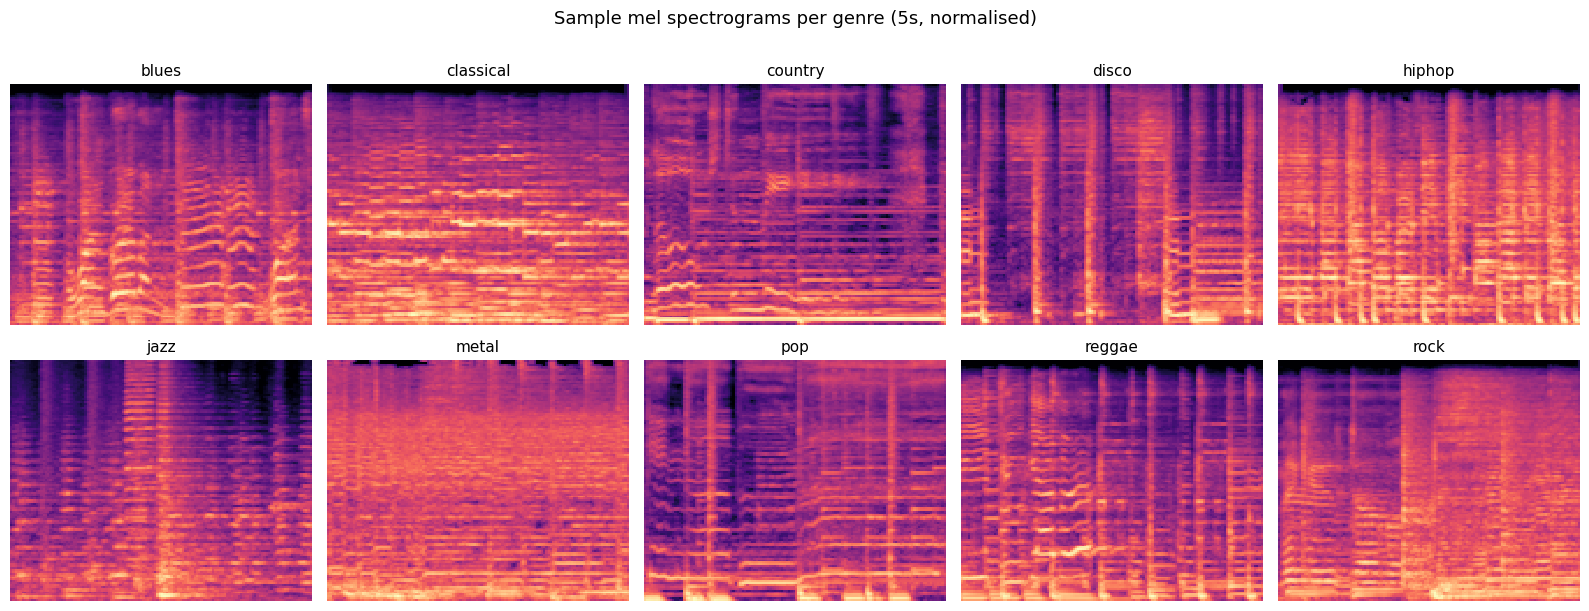

In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(16, 6))
for ax, genre in zip(axes.flat, le.classes_):
    idx = np.where(np.array(raw_labels) == genre)[0][0]
    img = X[idx, :, :, 0]
    im  = ax.imshow(img, aspect='auto', origin='lower',
                    cmap='magma', interpolation='nearest')
    ax.set_title(genre, fontsize=11)
    ax.axis('off')
plt.suptitle(f'Sample mel spectrograms per genre ({SEGMENT_DURATION:.0f}s, normalised)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 5. Track-Level Train / Validation / Test Split
> **Critical:** split by track ID, not by segment — prevents data leakage.

In [ ]:
def split_by_track(X, y, track_ids,
                   test_size=TEST_SIZE, val_size=VAL_SIZE, seed=SEED):
    """
    1. Split unique tracks into train / val / test.
    2. Expand back to segment level.
    Guarantees no track appears in more than one split.
    """
    unique_tracks  = np.unique(track_ids)
    # One label per track (take the label of its first segment)
    track_label    = np.array([
        y[np.where(track_ids == t)[0][0]] for t in unique_tracks
    ])

    train_tracks, temp_tracks = train_test_split(
        unique_tracks, test_size=test_size + val_size,
        stratify=track_label, random_state=seed)

    temp_label = np.array([
        y[np.where(track_ids == t)[0][0]] for t in temp_tracks
    ])
    val_tracks, test_tracks = train_test_split(
        temp_tracks,
        test_size=test_size / (test_size + val_size),
        stratify=temp_label, random_state=seed)

    train_mask = np.isin(track_ids, train_tracks)
    val_mask   = np.isin(track_ids, val_tracks)
    test_mask  = np.isin(track_ids, test_tracks)

    return (X[train_mask], y[train_mask], track_ids[train_mask],
            X[val_mask],   y[val_mask],   track_ids[val_mask],
            X[test_mask],  y[test_mask],  track_ids[test_mask])


X_train, y_train, track_ids_train, \
X_val, y_val, track_ids_val, \
X_test, y_test, track_ids_test = split_by_track(
    X, y, track_ids)

print(f'Train : {len(X_train):>7,} segments  ({100*len(X_train)/len(X):.1f}%)')
print(f'Val   : {len(X_val):>7,} segments  ({100*len(X_val)/len(X):.1f}%)')
print(f'Test  : {len(X_test):>7,} segments  ({100*len(X_test)/len(X):.1f}%)')

Train :  13,273 segments  (70.0%)
Val   :   2,850 segments  (15.0%)
Test  :   2,849 segments  (15.0%)


## 6. tf.data Pipelines with SpecAugment

In [ ]:
def spec_augment(spectrogram, label):
    """
    SpecAugment: randomly mask time steps and frequency bands.
    Safe for spectrograms — no vertical flip (frequency axis is meaningful).
    """
    spec = spectrogram
    freq_bins  = tf.shape(spec)[0]
    time_steps = tf.shape(spec)[1]

    # ── Time masking ──────────────────────────────────────────
    t  = tf.random.uniform((), 0, time_steps // 8, dtype=tf.int32)
    t0 = tf.random.uniform((), 0, time_steps - t,  dtype=tf.int32)
    time_mask = tf.concat([
        tf.ones ([freq_bins, t0,               1], dtype=spec.dtype),
        tf.zeros([freq_bins, t,                1], dtype=spec.dtype),
        tf.ones ([freq_bins, time_steps-t0-t,  1], dtype=spec.dtype),
    ], axis=1)
    spec = spec * time_mask

    # ── Frequency masking ─────────────────────────────────────
    f  = tf.random.uniform((), 0, freq_bins // 8, dtype=tf.int32)
    f0 = tf.random.uniform((), 0, freq_bins - f,  dtype=tf.int32)
    freq_mask = tf.concat([
        tf.ones ([f0,          time_steps, 1], dtype=spec.dtype),
        tf.zeros([f,           time_steps, 1], dtype=spec.dtype),
        tf.ones ([freq_bins-f0-f, time_steps, 1], dtype=spec.dtype),
    ], axis=0)
    spec = spec * freq_mask

    # ── Mild amplitude jitter ─────────────────────────────────
    spec = tf.image.random_brightness(spec, max_delta=0.05)
    spec = tf.clip_by_value(spec, 0.0, 1.0)

    return spec, label


def make_dataset(X, y, augment=False, batch_size=BATCH_SIZE):
    ds = tf.data.Dataset.from_tensor_slices((X, y))
    if augment:
        ds = ds.shuffle(buffer_size=len(X), seed=SEED)
        ds = ds.map(spec_augment, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds


train_ds = make_dataset(X_train, y_train, augment=True)
val_ds   = make_dataset(X_val,   y_val,   augment=False)
test_ds  = make_dataset(X_test,  y_test,  augment=False)

print('Datasets ready.')
print(f'  Train batches : {len(train_ds)}')
print(f'  Val batches   : {len(val_ds)}')
print(f'  Test batches  : {len(test_ds)}')

Datasets ready.
  Train batches : 415
  Val batches   : 90
  Test batches  : 90


## 7. Model Definition

In [ ]:
def build_model(input_shape, num_classes):
    """
    Small CNN tuned for ~10k tracks (after segmentation ~110k segments).
    Design choices:
      - ELU activations    : prevents dying neurons, smooth gradients
      - BatchNormalization : faster convergence, mild regularisation
      - Conv → BN → ELU   : canonical ordering
      - GlobalAveragePooling: far fewer params than Flatten
      - Progressive Dropout: 0.2 early → 0.5 in head
      - L2 regularisation  : 1e-3, stronger than large-data models
    """
    REG = l2(1e-3)

    model = Sequential([

        # ── Block 1 ───────────────────────────────────────────
        Conv2D(16, (3,3), padding='same',
               kernel_regularizer=REG, input_shape=input_shape),
        BatchNormalization(),
        ELU(alpha=1.0),
        MaxPooling2D((2,2)),
        Dropout(0.2),

        # ── Block 2 ───────────────────────────────────────────
        Conv2D(32, (3,3), padding='same', kernel_regularizer=REG),
        BatchNormalization(),
        ELU(alpha=1.0),
        MaxPooling2D((2,2)),
        Dropout(0.25),

        # ── Block 3 ───────────────────────────────────────────
        Conv2D(64, (3,3), padding='same', kernel_regularizer=REG),
        BatchNormalization(),
        ELU(alpha=1.0),
        GlobalAveragePooling2D(),
        Dropout(0.4),

        # ── Classifier head ───────────────────────────────────
        Dense(64, kernel_regularizer=REG),
        BatchNormalization(),
        ELU(alpha=1.0),
        Dropout(0.5),

        Dense(num_classes, activation='softmax')
    ])

    model.compile(
        optimizer=Adam(learning_rate=LEARNING_RATE),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


input_shape = X_train.shape[1:]   # (n_mels, time_frames, 1)
model = build_model(input_shape, num_classes)
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 130, 16)   │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 130, 16)   │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ elu (ELU)                       │ (None, 128, 130, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 65, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 65, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 65, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 65, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ elu_1 (ELU)                     │ (None, 64, 65, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ elu_2 (ELU)                     │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ elu_3 (ELU)                     │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,810 (112.54 KB)

 Trainable params: 28,458 (111.16 KB)

 Non-trainable params: 352 (1.38 KB)

## 8. Callbacks & Training

In [ ]:
callbacks = [
    # Halve LR when val_loss stalls for 8 epochs
    ReduceLROnPlateau(
        monitor='val_loss', factor=0.5,
        patience=8, min_lr=1e-6, verbose=1
    ),
    # Stop when val_loss hasn't improved for 15 epochs;
    # restore best weights automatically
    EarlyStopping(
        monitor='val_loss', patience=15,
        restore_best_weights=True, verbose=1
    ),
    # Save best checkpoint to disk (same monitor as early stopping)
    ModelCheckpoint(
        'best_model.keras', monitor='val_loss',
        save_best_only=True, verbose=0
    )
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

# Ensure all downstream evaluation uses the checkpoint chosen by val_loss.
if Path('best_model.keras').exists():
    model = tf.keras.models.load_model('best_model.keras')

print(f'\nTraining stopped at epoch {len(history.history["loss"])}')


Epoch 1/150
415/415 ━━━━━━━━━━━━━━━━━━━━ 27s 37ms/step - accuracy: 0.2314 - loss: 2.4349 - val_accuracy: 0.1053 - val_loss: 4.3339 - learning_rate: 0.0010
Epoch 2/150
415/415 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.3556 - loss: 1.8799 - val_accuracy: 0.1975 - val_loss: 3.0314 - learning_rate: 0.0010
Epoch 3/150
415/415 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.4034 - loss: 1.7111 - val_accuracy: 0.1965 - val_loss: 4.3897 - learning_rate: 0.0010
Epoch 4/150
415/415 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.4513 - loss: 1.5836 - val_accuracy: 0.3730 - val_loss: 2.2502 - learning_rate: 0.0010
Epoch 5/150
415/415 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.4928 - loss: 1.4987 - val_accuracy: 0.4488 - val_loss: 1.6299 - learning_rate: 0.0010
Epoch 6/150
415/415 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.5179 - loss: 1.4383 - val_accuracy: 0.5067 - val_loss: 1.4534 - learning_rate: 0.0010
Epoch 7/150
415/415 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.5323 -

## 9. Training Curves

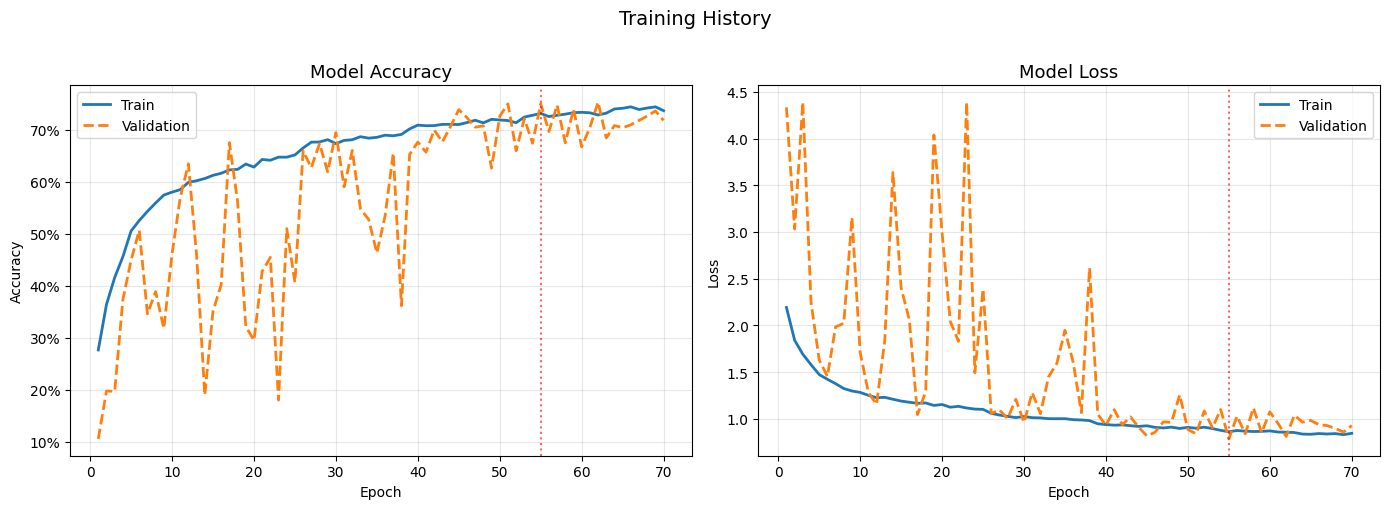

Best epoch (lowest val_loss): 55


In [ ]:
def plot_history(history):
    epochs_ran = range(1, len(history.history['loss']) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # ── Accuracy ──────────────────────────────────────────────
    axes[0].plot(epochs_ran, history.history['accuracy'],
                 label='Train', linewidth=2)
    axes[0].plot(epochs_ran, history.history['val_accuracy'],
                 label='Validation', linewidth=2, linestyle='--')
    axes[0].set_title('Model Accuracy', fontsize=13)
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1))
    axes[0].grid(alpha=0.3)

    # ── Loss ──────────────────────────────────────────────────
    axes[1].plot(epochs_ran, history.history['loss'],
                 label='Train', linewidth=2)
    axes[1].plot(epochs_ran, history.history['val_loss'],
                 label='Validation', linewidth=2, linestyle='--')
    axes[1].set_title('Model Loss', fontsize=13)
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    # Annotate early-stopping point
    best_ep = np.argmin(history.history['val_loss']) + 1
    for ax in axes:
        ax.axvline(best_ep, color='red', linestyle=':', alpha=0.6,
                   label=f'Best epoch ({best_ep})')

    plt.suptitle('Training History', fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()
    print(f'Best epoch (lowest val_loss): {best_ep}')


plot_history(history)

## 10. Evaluation on Test Set

In [ ]:
# ── Segment-level evaluation ──────────────────────────────────
test_loss, test_acc = model.evaluate(test_ds, verbose=0)
print(f'Test loss     : {test_loss:.4f}')
print(f'Test accuracy : {test_acc:.4f}  ({test_acc*100:.2f}%)')

# ── Predictions ───────────────────────────────────────────────
y_pred_prob = model.predict(test_ds, verbose=0)
y_pred      = np.argmax(y_pred_prob, axis=1)

Test loss     : 1.0499
Test accuracy : 0.7364  (73.64%)


## 11. Classification Report

In [ ]:
print('Classification Report (segment level)\n')
print(classification_report(
    y_test, y_pred,
    target_names=le.classes_,
    digits=3
))

Classification Report (segment level)

              precision    recall  f1-score   support

       blues      0.702     0.895     0.787       285
   classical      0.737     0.947     0.829       284
     country      0.752     0.586     0.659       285
       disco      0.694     0.628     0.659       285
      hiphop      0.945     0.730     0.824       285
        jazz      0.823     0.751     0.785       285
       metal      0.712     0.937     0.809       285
         pop      0.758     0.825     0.790       285
      reggae      0.691     0.800     0.741       285
        rock      0.521     0.267     0.353       285

    accuracy                          0.736      2849
   macro avg      0.734     0.736     0.724      2849
weighted avg      0.734     0.736     0.724      2849



## 12. Confusion Matrix

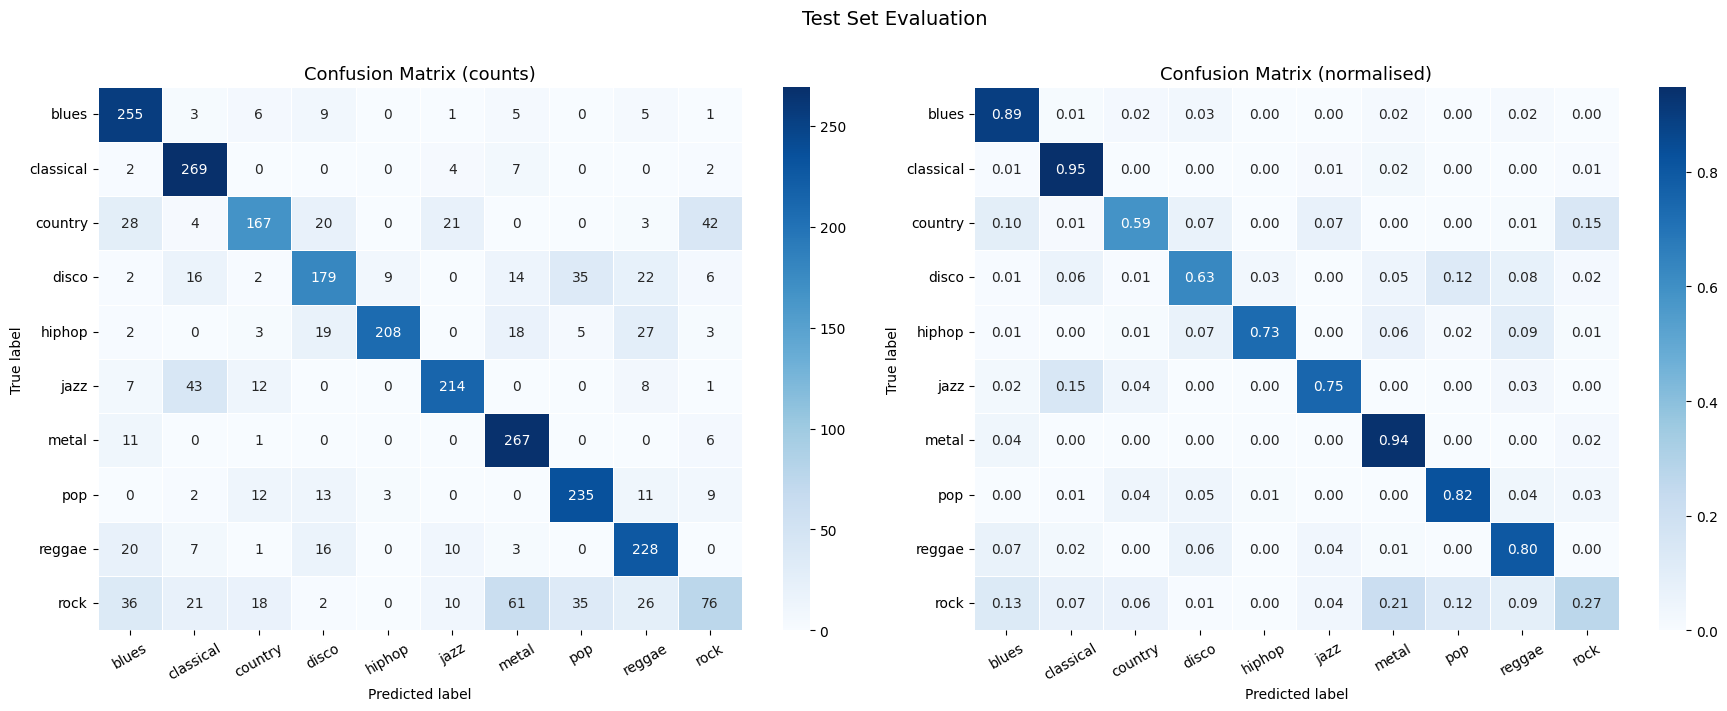

In [ ]:
def plot_confusion_matrix(y_true, y_pred, class_names):
    cm  = confusion_matrix(y_true, y_pred)
    # Normalise by true count → recall per class
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    fig, axes = plt.subplots(1, 2, figsize=(18, 7))

    for ax, data, title, fmt in zip(
        axes,
        [cm, cm_norm],
        ['Confusion Matrix (counts)', 'Confusion Matrix (normalised)'],
        ['d', '.2f']
    ):
        sns.heatmap(
            data, annot=True, fmt=fmt,
            xticklabels=class_names, yticklabels=class_names,
            cmap='Blues', linewidths=0.5,
            ax=ax, cbar=True
        )
        ax.set_title(title, fontsize=13)
        ax.set_xlabel('Predicted label')
        ax.set_ylabel('True label')
        ax.tick_params(axis='x', rotation=30)

    plt.suptitle('Test Set Evaluation', fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()


plot_confusion_matrix(y_test, y_pred, le.classes_)

## 13. Per-Class Accuracy Bar Chart

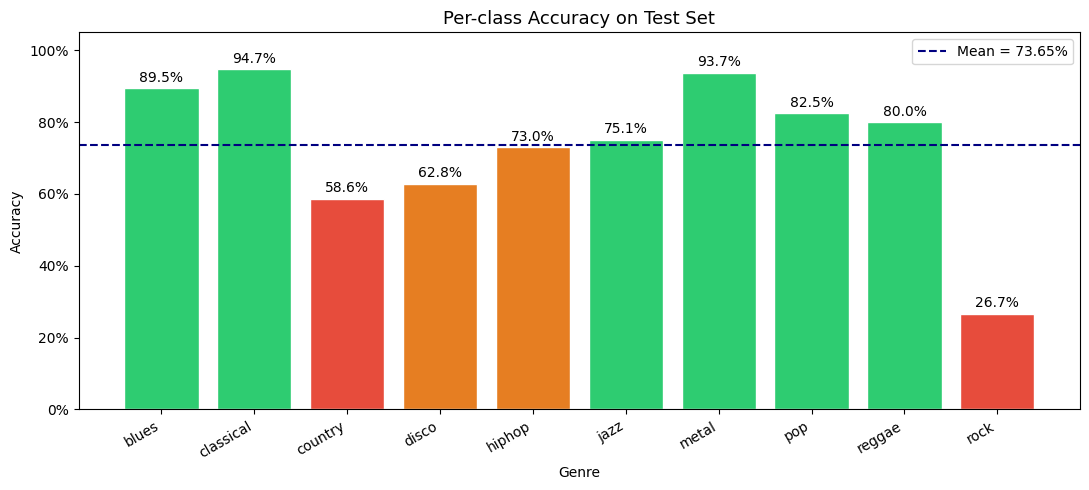

In [ ]:
def plot_per_class_accuracy(y_true, y_pred, class_names):
    cm       = confusion_matrix(y_true, y_pred)
    per_cls  = cm.diagonal() / cm.sum(axis=1)
    colours  = ['#2ecc71' if v >= 0.75
                else '#e67e22' if v >= 0.60
                else '#e74c3c' for v in per_cls]

    fig, ax = plt.subplots(figsize=(11, 5))
    bars = ax.bar(class_names, per_cls, color=colours, edgecolor='white')
    ax.axhline(per_cls.mean(), color='navy', linestyle='--',
               linewidth=1.5, label=f'Mean = {per_cls.mean():.2%}')
    ax.set_ylim(0, 1.05)
    ax.yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1))
    ax.set_title('Per-class Accuracy on Test Set', fontsize=13)
    ax.set_xlabel('Genre')
    ax.set_ylabel('Accuracy')
    ax.legend()
    plt.xticks(rotation=30, ha='right')

    # Value labels on bars
    for bar, val in zip(bars, per_cls):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.01,
                f'{val:.1%}', ha='center', va='bottom', fontsize=10)

    plt.tight_layout()
    plt.show()


plot_per_class_accuracy(y_test, y_pred, le.classes_)

## 14. Track-Level Majority Vote Evaluation

In [ ]:
from scipy import stats

def majority_vote_accuracy(X_test, y_test, track_ids_test, model):
    """
    For each unique track in the test set, aggregate segment predictions
    via majority vote and compute track-level accuracy.
    """
    # Get segment-level predictions
    probs  = model.predict(X_test, verbose=0, batch_size=BATCH_SIZE)
    preds  = np.argmax(probs, axis=1)

    track_true, track_pred = [], []
    for track_id in np.unique(track_ids_test):
        mask = track_ids_test == track_id
        vote = stats.mode(preds[mask], keepdims=True).mode[0]
        true = y_test[mask][0]
        track_pred.append(vote)
        track_true.append(true)

    track_true = np.array(track_true)
    track_pred = np.array(track_pred)
    acc = np.mean(track_true == track_pred)

    print(f'Track-level accuracy (majority vote): {acc:.4f}  ({acc*100:.2f}%)')
    print(f'Segment-level accuracy               : {test_acc:.4f}  ({test_acc*100:.2f}%)')
    print(f'Improvement from majority vote       : +{(acc - test_acc)*100:.2f}%')

    print('\nTrack-level Classification Report:\n')
    print(classification_report(track_true, track_pred,
                                target_names=le.classes_, digits=3))
    return track_true, track_pred, acc


# Track IDs are already returned by split_by_track and aligned with X_test/y_test.
track_true, track_pred, track_acc = majority_vote_accuracy(
    X_test, y_test,
    track_ids_test, # Use the correctly extracted test track IDs
    model
)

Track-level accuracy (majority vote): 0.8000  (80.00%)
Segment-level accuracy               : 0.7364  (73.64%)
Improvement from majority vote       : +6.36%

Track-level Classification Report:

              precision    recall  f1-score   support

       blues      0.789     1.000     0.882        15
   classical      0.778     0.933     0.848        15
     country      0.786     0.733     0.759        15
       disco      0.917     0.733     0.815        15
      hiphop      1.000     0.800     0.889        15
        jazz      0.857     0.800     0.828        15
       metal      0.682     1.000     0.811        15
         pop      0.867     0.867     0.867        15
      reggae      0.722     0.867     0.788        15
        rock      0.667     0.267     0.381        15

    accuracy                          0.800       150
   macro avg      0.806     0.800     0.787       150
weighted avg      0.806     0.800     0.787       150



## 15. Summary

In [ ]:
print('=' * 52)
print('           EXPERIMENT SUMMARY')
print('=' * 52)
print(f'  Genres             : {num_classes}')
print(f'  Total segments     : {len(X):,}')
print(f'  Segment duration   : {SEGMENT_DURATION}s  (overlap {int(OVERLAP*100)}%)')
print(f'  Train / Val / Test : {len(X_train):,} / {len(X_val):,} / {len(X_test):,}')
print(f'  Epochs trained     : {len(history.history["loss"])}')
print(f'  Batch size         : {BATCH_SIZE}')
print('-' * 52)
print(f'  Test loss          : {test_loss:.4f}')
print(f'  Test accuracy      : {test_acc*100:.2f}%')
print('=' * 52)
if 'track_acc' in globals():
    print(f'  Track-level accuracy: {track_acc*100:.2f}%')
    print(f'  Delta (track - segment): {(track_acc - test_acc)*100:+.2f}%')


           EXPERIMENT SUMMARY
  Genres             : 10
  Total segments     : 18,972
  Segment duration   : 3.0s  (overlap 50%)
  Train / Val / Test : 13,273 / 2,850 / 2,849
  Epochs trained     : 70
  Batch size         : 32
----------------------------------------------------
  Test loss          : 1.0499
  Test accuracy      : 73.64%


## 16. Deeper understanding

90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


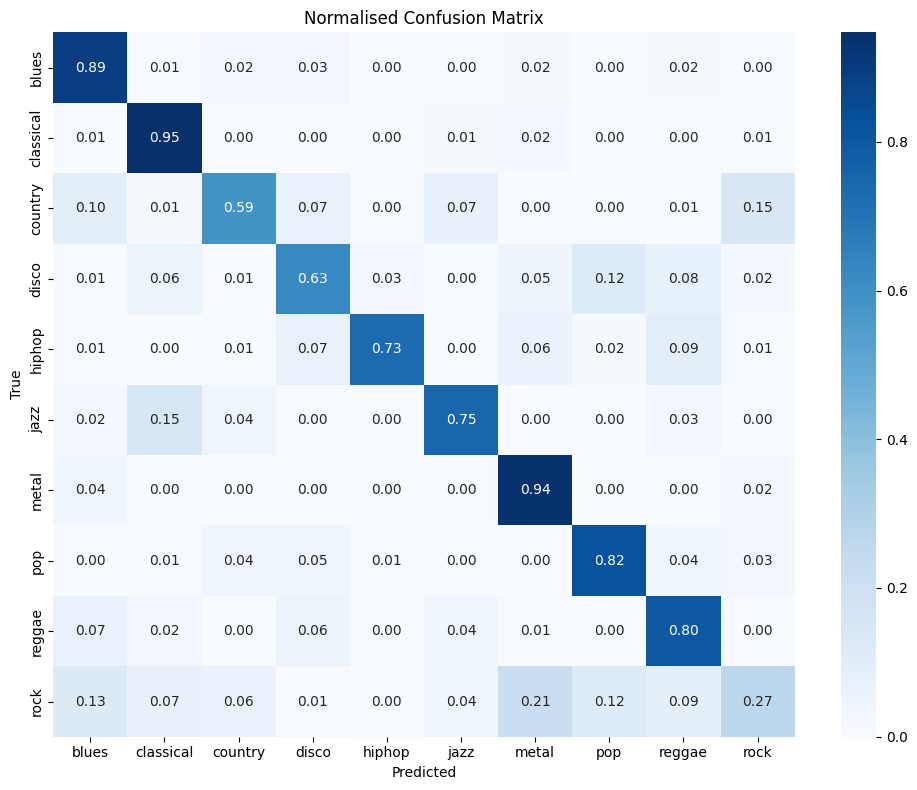

  rock        : 26.7%
  country     : 58.6%
  disco       : 62.8%
  hiphop      : 73.0%
  jazz        : 75.1%
  reggae      : 80.0%
  pop         : 82.5%
  blues       : 89.5%
  metal       : 93.7%
  classical   : 94.7%


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

y_pred = np.argmax(model.predict(test_ds), axis=1)
cm     = confusion_matrix(y_test, y_pred, normalize='true')

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_, ax=ax)
ax.set_title('Normalised Confusion Matrix')
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
plt.tight_layout()
plt.show()

# Print the worst-performing classes
per_class_acc = cm.diagonal()
for genre, acc in sorted(zip(le.classes_, per_class_acc), key=lambda x: x[1]):
    print(f'  {genre:<12}: {acc:.1%}')